<a href="https://colab.research.google.com/github/RandiBro234/Machine-Learning-Workflow-/blob/main/Machine_Learning_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **IMPORT DATASET**

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd
df = pd.read_csv("Student_performance_data.csv")
print("Shape:", df.shape)
print("Ini adalah datanya: ", df.head())

Saving Student_performance_data.csv to Student_performance_data (2).csv
Shape: (2392, 15)
Ini adalah datanya:     StudentID  Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  \
0       1001   17       1          0                  2        19.833723   
1       1002   18       0          0                  1        15.408756   
2       1003   15       0          2                  3         4.210570   
3       1004   17       1          0                  3        10.028829   
4       1005   17       1          0                  2         4.672495   

   Absences  Tutoring  ParentalSupport  Extracurricular  Sports  Music  \
0         7         1                2                0       0      1   
1         0         0                1                0       0      0   
2        26         0                2                0       0      0   
3        14         0                3                1       0      0   
4        17         1                3                0       

# **EKSPLORATORY DATA ANALYSIS (EDA)**

=== INFORMASI DATA ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                2392 non-null   int64  
 1   Gender             2392 non-null   int64  
 2   Ethnicity          2392 non-null   int64  
 3   ParentalEducation  2392 non-null   int64  
 4   StudyTimeWeekly    2392 non-null   float64
 5   Absences           2392 non-null   int64  
 6   Tutoring           2392 non-null   int64  
 7   ParentalSupport    2392 non-null   int64  
 8   Extracurricular    2392 non-null   int64  
 9   Sports             2392 non-null   int64  
 10  Music              2392 non-null   int64  
 11  Volunteering       2392 non-null   int64  
 12  GPA                2392 non-null   float64
 13  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(11)
memory usage: 261.8 KB
None

=== CEK MISSING VALUE ===
Age              

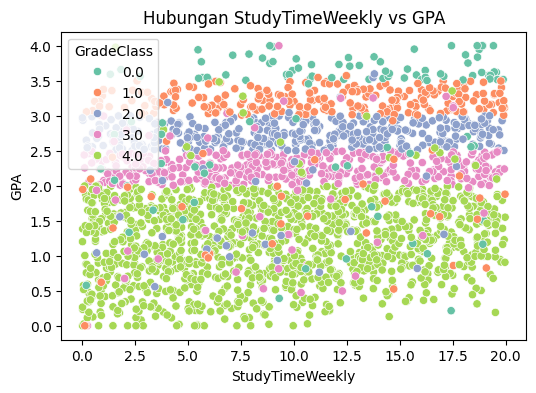

/tmp/ipython-input-2757795289.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='ParentalSupport', y='GPA', palette='mako')


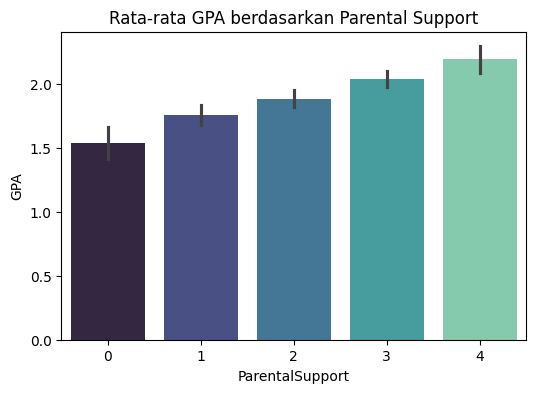

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Lihat informasi umum dataset
print("=== INFORMASI DATA ===")
print(df.info())

# 2. Cek missing values
print("\n=== CEK MISSING VALUE ===")
print(df.isnull().sum())

# 3. Statistik deskriptif
print("\n=== STATISTIK DESKRIPTIF ===")
print(df.describe())

# 4. Deteksi Outlier (menggunakan IQR)
print("\n=== DETEKSI OUTLIER DENGAN IQR ===")
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    print(f"{col}: {len(outliers)} outlier")


# 5. Hubungan antara waktu belajar mingguan dan GPA
plt.figure(figsize=(6,4))
sns.scatterplot(data=df, x='StudyTimeWeekly', y='GPA', hue='GradeClass', palette='Set2')
plt.title('Hubungan StudyTimeWeekly vs GPA')
plt.show()

# 6. Rata-rata GPA berdasarkan dukungan orang tua
plt.figure(figsize=(6,4))
sns.barplot(data=df, x='ParentalSupport', y='GPA', palette='mako')
plt.title('Rata-rata GPA berdasarkan Parental Support')
plt.show()


# **PREPROCESSING DATA**

In [7]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler

# 1. CEK missing value
print("=== CEK MISSING VALUE ===")
print(df.isnull().sum())

# Isi missing value dengan median (hanya untuk kolom numerik)
df.fillna(df.median(numeric_only=True), inplace=True)

# 2. HAPUS kolom yang tidak relevan
if 'StudentID' in df.columns:
    df.drop(columns=['StudentID'], inplace=True)

# 3. Tentukan kolom kategorikal dan numerik kontinu
categorical_cols = ['Gender', 'Ethnicity', 'ParentalEducation',
                    'Tutoring', 'ParentalSupport', 'Extracurricular',
                    'Sports', 'Music', 'Volunteering']

numeric_cols = ['Age', 'StudyTimeWeekly', 'Absences', 'GPA']

# Pastikan kolom yang disebut benar-benar ada di dataset
categorical_cols = [col for col in categorical_cols if col in df.columns]
numeric_cols = [col for col in numeric_cols if col in df.columns]

# 4. ENCODING kolom kategorikal
encoder = LabelEncoder()
for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

print("\n=== Contoh data setelah encoding ===")
print(df.head())

# 5. PISAHKAN fitur (X) dan target (y)
X = df.drop(columns=['GradeClass'])
y = df['GradeClass']

# 6. SCALING hanya untuk kolom numerik kontinu
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numeric_cols] = scaler.fit_transform(X[numeric_cols])

print("\n=== Data setelah scaling (hanya numerik kontinu) ===")
print(X_scaled.head())

# 7. CEK hasil akhir
print("\nShape fitur:", X_scaled.shape)
print("Shape target:", y.shape)


=== CEK MISSING VALUE ===
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

=== Contoh data setelah encoding ===
   Age  Gender  Ethnicity  ParentalEducation  StudyTimeWeekly  Absences  \
0   17       1          0                  2        19.833723         7   
1   18       0          0                  1        15.408756         0   
2   15       0          2                  3         4.210570        26   
3   17       1          0                  3        10.028829        14   
4   17       1          0                  2         4.672495        17   

   Tutoring  ParentalSupport  Extracurricular  Sports  Music  Volunteering  \
0         1                2                0       0      1            

# **MODEL SELECTION**

In [21]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Model baseline - Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)
acc_log = accuracy_score(y_test, y_pred_log)

# 3. Model utama - Random Forest
rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)

# 4. Bandingkan akurasi
print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print(f"Random Forest Accuracy: {acc_rf:.4f}")

# 5. Evaluasi terbaik
print("\n=== Classification Report (Random Forest) ===")
print(classification_report(y_test, y_pred_rf))

Logistic Regression Accuracy: 0.8017
Random Forest Accuracy: 0.9102

=== Classification Report (Random Forest) ===
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.82      0.85      0.84        54
         2.0       0.89      0.95      0.92        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.91       479
   macro avg       0.91      0.79      0.81       479
weighted avg       0.91      0.91      0.90       479



# **FEATURE IMPORTANCE**

=== FEATURE IMPORTANCE ===
              Feature  Importance
12                GPA    0.522719
5            Absences    0.221985
4     StudyTimeWeekly    0.079234
7     ParentalSupport    0.032711
3   ParentalEducation    0.026638
0                 Age    0.024621
2           Ethnicity    0.023120
1              Gender    0.013142
9              Sports    0.012595
8     Extracurricular    0.012176
6            Tutoring    0.011681
10              Music    0.009759
11       Volunteering    0.009621


/tmp/ipython-input-3409149603.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')


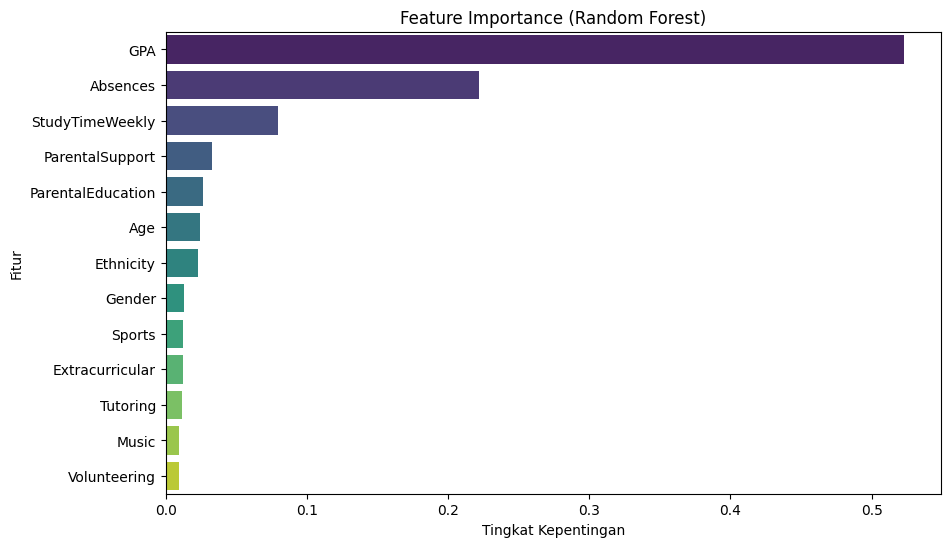

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Ambil nilai pentingnya setiap fitur dari model Random Forest
importances = rf_model.feature_importances_
feature_names = X_scaled.columns

# Gabungkan ke DataFrame untuk urutan dan visualisasi
feat_imp = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Tampilkan tabel feature importance
print("=== FEATURE IMPORTANCE ===")
print(feat_imp)

# Visualisasikan dengan barplot
plt.figure(figsize=(10,6))
sns.barplot(data=feat_imp, x='Importance', y='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.xlabel('Tingkat Kepentingan')
plt.ylabel('Fitur')
plt.show()


# **DATA SPLITING**

In [18]:
from sklearn.model_selection import train_test_split

# Misalnya target prediksi adalah GradeClass
X = X_scaled
y = df['GradeClass']

# Bagi data menjadi train dan test (80% : 20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,       # 20% data untuk testing
    random_state=42,     # agar hasil bisa direproduksi
    stratify=y           # menjaga proporsi kelas tetap seimbang
)

print("Ukuran data latih (train):", X_train.shape)
print("Ukuran data uji (test):", X_test.shape)
print("Distribusi kelas di data latih:")
print(y_train.value_counts(normalize=True))
print("\nDistribusi kelas di data uji:")
print(y_test.value_counts(normalize=True))


Ukuran data latih (train): (1913, 13)
Ukuran data uji (test): (479, 13)
Distribusi kelas di data latih:
GradeClass
4.0    0.506012
3.0    0.173027
2.0    0.163617
1.0    0.112389
0.0    0.044956
Name: proportion, dtype: float64

Distribusi kelas di data uji:
GradeClass
4.0    0.507307
3.0    0.173278
2.0    0.162839
1.0    0.112735
0.0    0.043841
Name: proportion, dtype: float64


# **MODEL TRAINING**

Accuracy Model Random Forest: 0.9123

=== Classification Report ===
              precision    recall  f1-score   support

         0.0       1.00      0.29      0.44        21
         1.0       0.82      0.87      0.85        54
         2.0       0.90      0.95      0.93        78
         3.0       0.89      0.89      0.89        83
         4.0       0.94      0.97      0.96       243

    accuracy                           0.91       479
   macro avg       0.91      0.79      0.81       479
weighted avg       0.92      0.91      0.90       479



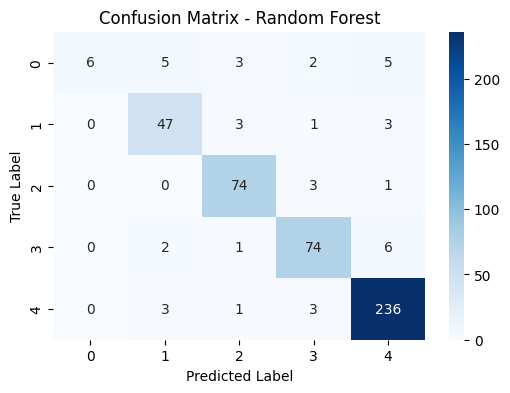

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Inisialisasi model
rf_model = RandomForestClassifier(
    n_estimators=100,     # jumlah pohon
    random_state=42,      # untuk hasil yang konsisten
    max_depth=None,       # biarkan pohon tumbuh penuh
    n_jobs=-1             # gunakan semua core CPU
)

# 2. Latih model
rf_model.fit(X_train, y_train)

# 3. Prediksi data uji
y_pred = rf_model.predict(X_test)

# 4. Evaluasi performa awal
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Model Random Forest: {acc:.4f}")
print("\n=== Classification Report ===")
print(classification_report(y_test, y_pred))

# 5. Visualisasi confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


# **MODEL EVALUATION**

In [22]:
#AUC
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarisasi target (karena multi-class)
y_test_bin = label_binarize(y_test, classes=sorted(y.unique()))
y_pred_prob = rf_model.predict_proba(X_test)

# Hitung AUC
auc = roc_auc_score(y_test_bin, y_pred_prob, average='macro')
print(f"AUC Score (macro average): {auc:.4f}")


AUC Score (macro average): 0.9017


In [23]:
# Cross Validation
from sklearn.model_selection import cross_val_score

# Lakukan 5-fold cross-validation
cv_scores = cross_val_score(rf_model, X_scaled, y, cv=5, scoring='accuracy')

print("Cross-Validation Scores:", cv_scores)
print("Mean Accuracy:", np.mean(cv_scores))
print("Standard Deviation:", np.std(cv_scores))


Cross-Validation Scores: [0.9874739  0.98329854 0.9874477  0.9539749  0.68200837]
Mean Accuracy: 0.9188406809863645
Standard Deviation: 0.11907662658555454
